## 1. Setup & Daten laden



In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('./data/online_retail_II.csv'
#,sep=';', thousands='.', decimal=','
, parse_dates=['InvoiceDate']
#, na_values='???'
)



## 2. Daten einlesen & erste Inspektion


In [4]:
print('Zeilen, Spalten:', df.shape)
df.head()

Zeilen, Spalten: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
print(df.dtypes, "\n")
for col in df.columns:
    print(col, df[col].nunique())


Invoice                   str
StockCode            category
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID          category
Country              category
dtype: object 

Invoice 53628
StockCode 5305
Description 5698
Quantity 1057
InvoiceDate 47635
Price 2807
Customer ID 5942
Country 43


In [5]:
col = ['Customer ID', 'Country', 'StockCode']
df[col] = df[col].astype('category') 

In [6]:

print("=" * 80)
print("📋 DATENÜBERSICHT")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"🔄 Duplikate: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"💾 Speichernutzung: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



📋 DATENÜBERSICHT

🔢 Dimensionen: 1,067,371 Zeilen × 8 Spalten
🔄 Duplikate: 34,335 (3.22%)
💾 Speichernutzung: 162.70 MB


In [7]:
df.dtypes# Detaillierte Spaltenübersicht
column_info = pd.DataFrame({
    "Datentyp": df.dtypes,
    "Fehlende Werte": df.isnull().sum(),
    "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Werte": df.nunique(),
    "Not a Number Werte": df.isna().sum(),
    "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
                      if df[col].notna().sum() > 0 else [] 
                      for col in df.columns]
})

column_info = column_info.sort_values("Fehlend %", ascending=False)
column_info


,Datentyp,Fehlende Werte,Fehlend %,Unique Werte,Not a Number Werte,Beispielwerte
Customer ID,category,243007,22.77,5942,243007,"[18143.0, 17675.0, 13755.0]"
Description,str,4382,0.41,5698,4382,"[JUMBO BAG APPLES, RED RETROSPOT TISSUE BOX, S..."
StockCode,category,0,0.00,5305,0,"[22671, 22966, 22807]"
Invoice,str,0,0.00,53628,0,"[578260, 537196, 574476]"
Quantity,int64,0,0.00,1057,0,"[4, 24, 2]"
InvoiceDate,datetime64[us],0,0.00,47635,0,"[2010-08-09 13:18:00, 2011-11-21 09:51:00, 200..."
Price,float64,0,0.00,2807,0,"[2.1, 0.42, 5.91]"
Country,category,0,0.00,43,0,"[United Kingdom, United Kingdom, United Kingdom]"


In [8]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 2 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.94,172.71,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.65,123.55,-53594.36,1.25,2.1,4.15,38970.0


In [9]:
# 1. Erstelle die Hilfsspalte "Filter" und setze sie standardmäßig komplett auf 0
df['Filter'] = 0

In [10]:
(df[numeric_cols] < 0).sum()

Quantity    22950
Price           5
dtype: int64

In [11]:
mask = df[numeric_cols] < 0
df_m = df[mask]

In [12]:
df.duplicated().sum()

np.int64(34335)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(1033036, 9)

In [15]:
#Überprüfung der Spalte Invoice auf C...  Wieviele EInträge gibt es davon?
anzahl_c = df['Invoice'].str.startswith(('c', 'C'), na=False).sum()
anzahl_c

np.int64(19104)

In [16]:
# Zählt alle Einträge, die KEINE reine Zahl sind
anzahl_keine_zahl = (~df['Invoice'].str.isnumeric()).sum()
anzahl_keine_zahl

np.int64(19110)

In [17]:
#Prüfung der C-Invoices:
# Erstellt die Bedingung (True/False-Maske)
maske_c = df['Invoice'].str.startswith(('c', 'C'), na=False)

# Filtert das DataFrame und zeigt die ersten 10 Zeilen an
df[maske_c].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,0
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,0
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,0
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,0
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,0
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,0
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,0
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,0
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,0


Scheinbar haben alle C... Invoices ein negatives Quantity. Aber es gibt 19.104 C-Invoices und 22.950 Einträge mit neg. Quantity
1. Haben alle C-Invoices einen negativen Preis?
2. Haben alle neg Quantity Einträge eine C-Invoice? Wenn nicht, wie sehen sie aus?

In [18]:
#Prüfung:  1. Haben alle C-Invoices einen negativen Preis?

# Erstelle die Maske für alle C-Rechnungen
c_maske = df['Invoice'].str.startswith(('c', 'C'), na=False)

#maske für alle Quantity >=0
mask2 = df['Quantity'] >= 0

mask_all = c_maske & mask2

print("Anzahl der C-Rechnungen mit positiver/null Menge:", mask_all.sum())


df[mask_all]

Anzahl der C-Rechnungen mit positiver/null Menge: 1


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom,0


---

## "Bei der Prüfung von Retouren (C-Rechnungen) gab es einen einzelnen manuellen Datensatz ohne negative Menge, der vernachlässigbar ist."

In [19]:
# Haben alle neg Quantity Einträge eine C-Invoice? Wenn nicht, wie sehen sie aus?

#Schritt 1: alle Zeilen mit Quantity <0
mask1 = df['Quantity'] < 0
print('Anz neg Quantity in df', len(df[mask1]))

mask2 = df[mask1]['Invoice'].str.startswith(('c', 'C'), na=False)
mask = mask1 & ~mask2

print('Anz neg Quantity in df + nicht C-Invoice', len(df[mask]))

#Schreibe in all diesen Datensätzen bei Filter eine 2
df.loc[mask, 'Filter'] = 2

display(df[mask].tail())


Anz neg Quantity in df 22496
Anz neg Quantity in df + nicht C-Invoice 3393


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
1060794,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom,2
1060796,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,2
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom,2
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,2
1064386,581422,23169,smashed,-235,2011-12-08 15:24:00,0.0,NaN,United Kingdom,2




##Zusätzlich zu Kunden-Retouren (C-Rechnungen) existieren im Datensatz interne Lagerkorrekturen (z. B. für Beschädigungen oder Verluste) mit negativen Mengen und einem Preis von 0.0. Diese werden mit Filter = 2 gekennzeichnet. Somit kann man später nach Klärung diese Datensätze schnell finden und ggf. für kundenbezogene Verkaufsanalysen ausschließen (3.393 Datensätze)

In [20]:
#Alle nicht C-Invoices, die keine Zahl sind
maske_c = df['Invoice'].str.startswith(('c', 'C'), na=False)
mask_nonumber_invoice = (~df['Invoice'].str.isnumeric())

mask = ~maske_c & mask_nonumber_invoice
df.loc[mask, 'Filter'] = 1
df[mask]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,1
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,1
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,1
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,1
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,1
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,1


---

##Bei der Datenbereinigung sind mir spezielle Buchungssätze aufgefallen (StockCode 'B', Beschreibung 'Adjust bad debt' mit Alphanumerischen Rechnungsnummern wie A506401). Da es sich hierbei um rein buchhalterische Abschreibungen (Bad Debt) und keine echten Kundenkäufe handelt, filtere ich diese Zeilen für die Umsatz- und Warenkorbanalyse heraus. Filter =1

In [21]:
# Adjust bad debt
print('debt', df['Description'].str.contains('debt').sum())
print('B', df['StockCode'].str.contains('B').sum())
print('Adjust', df['Description'].str.contains('Adjust').sum())
print('bad', df['Description'].str.contains('bad').sum())

mask = df['Description'].str.contains('Adjust')
df[mask]

debt 6
B 35757
Adjust 79
bad 7


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
70975,495732,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:20:00,96.46,NaN,EIRE,0
70976,495733,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:21:00,68.34,14911.0,EIRE,0
70977,495735,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:22:00,201.56,12745.0,EIRE,0
70978,495734,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:22:00,205.82,14911.0,EIRE,0
70979,C495737,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:23:00,10.50,16154.0,United Kingdom,0
...,...,...,...,...,...,...,...,...,...
692101,550948,17109D,Adjustment,14,2011-04-21 15:56:00,0.00,NaN,United Kingdom,0
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,1
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,1
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,1


In [22]:
# Filtert alle Zeilen, deren Werte KEINE Zahlen enthalten, und holt die Uniques
#df[~df['StockCode'].astype(str).str.contains(r'\d', regex=True)]['StockCode'].unique()

#r'\d', regex=True: Sucht in jedem Text nach mindestens einer Ziffer (\d steht in Regex für "digit/Zahl"). Das liefert ein True, wenn eine Zahl drin ist
mask = ~df['StockCode'].astype(str).str.contains(r'\d', regex=True)

testvals = df[mask]['StockCode'].unique().tolist()
#print(df[mask]['StockCode'].unique().tolist())
#print(*testvals, sep='\n')

for index, val in enumerate(testvals, start=1):
    mask = df['StockCode'] == val
    print(f'Prüfwert {index}/{len(testvals)}, {val}: {len(df[mask])} Datensätze')
    display(df.loc[mask].head(5))
    


Prüfwert 1/17, POST: 2086 Datensätze


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.0,France,0
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA,0
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium,0
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533.0,Germany,0
927,C489538,POST,POSTAGE,-1,2009-12-01 12:18:00,9.58,15796.0,United Kingdom,0


Prüfwert 2/17, D: 173 Datensätze


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299.0,United Kingdom,0
736,C489535,D,Discount,-1,2009-12-01 12:11:00,19.00,15299.0,United Kingdom,0
24675,C491428,D,Discount,-1,2009-12-10 20:23:00,9.10,15494.0,United Kingdom,0
29414,C491845,D,Discount,-1,2009-12-14 14:54:00,1.59,NaN,United Kingdom,0
29958,C491962,D,Discount,-1,2009-12-14 16:38:00,0.59,13206.0,United Kingdom,0


Prüfwert 3/17, DOT: 1425 Datensätze


...

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,1
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,1
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,1
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,1
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,1


Prüfwert 16/17, AMAZONFEE: 36 Datensätze


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
440688,C531400,AMAZONFEE,AMAZON FEE,-1,2010-11-08 10:08:00,6706.71,NaN,United Kingdom,0
440698,531411,AMAZONFEE,AMAZON FEE,1,2010-11-08 10:11:00,6706.71,NaN,United Kingdom,0
517452,C537600,AMAZONFEE,AMAZON FEE,-1,2010-12-07 12:41:00,1.00,NaN,United Kingdom,0
517953,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom,0
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,0


Prüfwert 17/17, CRUK: 16 Datensätze


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
842969,C564763,CRUK,CRUK Commission,-1,2011-08-30 10:49:00,1.60,14096.0,United Kingdom,0
849464,C565382,CRUK,CRUK Commission,-1,2011-09-02 15:45:00,13.01,14096.0,United Kingdom,0
859206,C566216,CRUK,CRUK Commission,-1,2011-09-09 15:17:00,15.96,14096.0,United Kingdom,0
864273,C566565,CRUK,CRUK Commission,-1,2011-09-13 12:32:00,52.24,14096.0,United Kingdom,0
876043,C567655,CRUK,CRUK Commission,-1,2011-09-21 14:40:00,608.66,14096.0,United Kingdom,0


In [23]:
#Untersuchung aller fehlenden Werte bei Description
#alle NaNs bei Description mit kein Preis = 0
#alle NaNs bei Description mit positive Quantity:
#alle NaNs bei Description mit negative Quantity:
mask1 = df['Description'].isna()
mask_Qm = df['Quantity'] < 0
mask_Qp = df['Quantity'] > 0
mask_Q0 = df['Quantity'] == 0

mask = mask1 & mask_Qp 
print('alle NaNs bei Description mit positiver Quantity:', len(df[mask]))
mask = mask1 & mask_Qm
print('alle NaNs bei Description mit negativer Quantity:', len(df[mask]))
mask = mask1 & mask_Q0
print('alle NaNs bei Description mit Quantity = 0:', len(df[mask]))

mask_p0 = df['Price'] == 0
mask = mask1 & ~mask_p0
print('alle NaNs bei Description mit Preis = 0:', len(df[mask]))

alle NaNs bei Description mit positiver Quantity: 1642
alle NaNs bei Description mit negativer Quantity: 2633
alle NaNs bei Description mit Quantity = 0: 0
alle NaNs bei Description mit Preis = 0: 0


In [24]:
#Untersuchung der Price = 0 Datensätze
mask = df['Price'] == 0
df[mask]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,2
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,2
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,2
...,...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,0
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,0
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,0
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom,0


In [25]:
pd.options.display.float_format = '{:.2f}'.format
df['Quantity'].describe()

count   1033036.00
mean         10.08
std         175.20
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00
Name: Quantity, dtype: float64

In [26]:
#Untersuchung der Datensätze <-1000 Mengeneinheiten und ohne Filter 2
mask1 = df['Quantity'] < -1000
mask2 = df['Filter'] <2
mask = mask1 & mask2
df[mask]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
93676,C498151,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,-2504,2010-02-17 10:37:00,1.45,13902.00,Denmark,0
157466,C504415,84270,ASSTD DESIGN BUBBLE GUM RING,-1440,2010-04-13 12:33:00,0.16,12971.00,United Kingdom,0
197424,C508334,47587A,PINK FAIRY CAKE COASTER,-1200,2010-05-14 12:04:00,0.72,13694.00,United Kingdom,0
359630,C524235,16047,POP ART PEN CASE & PENS,-5184,2010-09-28 11:02:00,0.08,14277.00,France,0
359631,C524235,21280,VINTAGE KITCHEN PRINT VEGETABLES,-1248,2010-09-28 11:02:00,0.25,14277.00,France,0
359632,C524235,21281,VINTAGE KITCHEN PRINT SEAFOOD,-1536,2010-09-28 11:02:00,0.25,14277.00,France,0
359634,C524235,21392,RED POLKADOT PUDDING BOWL,-3648,2010-09-28 11:02:00,0.13,14277.00,France,0
359635,C524235,21393,BLUE POLKADOT PUDDING BOWL,-2496,2010-09-28 11:02:00,0.13,14277.00,France,0
359636,C524235,37340,MULTICOLOUR SPRING FLOWER MUG,-4992,2010-09-28 11:02:00,0.10,14277.00,France,0
359637,C524235,37423,WHITE WITH BLACK CATS PLATE,-2952,2010-09-28 11:02:00,0.10,14277.00,France,0


In [27]:
#Untersuchung der Datensätze mit Mengen über 4400
mask = df['Quantity'] > 4400
df[mask]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
7303,490018,21967,PACK OF 12 SKULL TISSUES,5184,2009-12-03 12:31:00,0.25,17940.00,United Kingdom,0
65077,495194,37410,BLACK AND WHITE PAISLEY FLOWER MUG,6012,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
65079,495194,16044,POP-ART FLUORESCENT PENS,6144,2010-01-21 15:11:00,0.06,13902.00,Denmark,0
65085,495194,20759,CHRYSANTHEMUM POCKET BOOK,5280,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
65086,495194,20758,ABSTRACT CIRCLES POCKET BOOK,4800,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
65087,495194,20757,RED DAISY POCKET BOOK,4800,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
65088,495194,20756,GREEN FERN POCKET BOOK,5280,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
65090,495194,20991,JAZZ HEARTS MAGNETIC MEMO PAD,6768,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
65091,495194,20993,JAZZ HEARTS MEMO PAD,9312,2010-01-21 15:11:00,0.10,13902.00,Denmark,0
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.00,Denmark,0


In [28]:
df['Price'].describe()

count   1033036.00
mean          4.61
std         122.40
min      -53594.36
25%           1.25
50%           2.10
75%           4.15
max       38970.00
Name: Price, dtype: float64

In [29]:
#Untersuchung der Datensätze mit negativen Preis 
mask = df['Price'] < 0
df[mask]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,1
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,1
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,1
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,1
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,1


In [30]:
#Untersuchung der Datensätze mit Preis über 10000 
mask = df['Price'] > 10000
df[mask]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Filter
135012,C502262,M,Manual,-1,2010-03-23 15:20:00,10953.50,12918.00,United Kingdom,0
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.00,United Kingdom,0
135014,C502264,M,Manual,-1,2010-03-23 15:24:00,10953.50,12918.00,United Kingdom,0
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,0
241824,C512770,M,Manual,-1,2010-06-17 16:52:00,25111.09,17399.00,United Kingdom,0
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,0
320581,C520667,BANK CHARGES,Bank Charges,-1,2010-08-27 13:42:00,18910.69,NaN,United Kingdom,0
342135,C522793,M,Manual,-1,2010-09-16 14:53:00,10468.80,14063.00,United Kingdom,0
342147,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,0
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.00,United Kingdom,0


In [31]:
# Prüft, ob der Rest ungleich 0 ist und schließt NaN-Werte (Lücken) sicher aus

anzahl_mit_nachkomma = (df['Customer ID'].astype('float') % 1 != 0)

print(f"Anzahl Werte mit Nachkommastellen: {anzahl_mit_nachkomma}")

    


Anzahl Werte mit Nachkommastellen: 0          False
1          False
2          False
3          False
4          False
           ...  
1067366    False
1067367    False
1067368    False
1067369    False
1067370    False
Name: Customer ID, Length: 1033036, dtype: bool


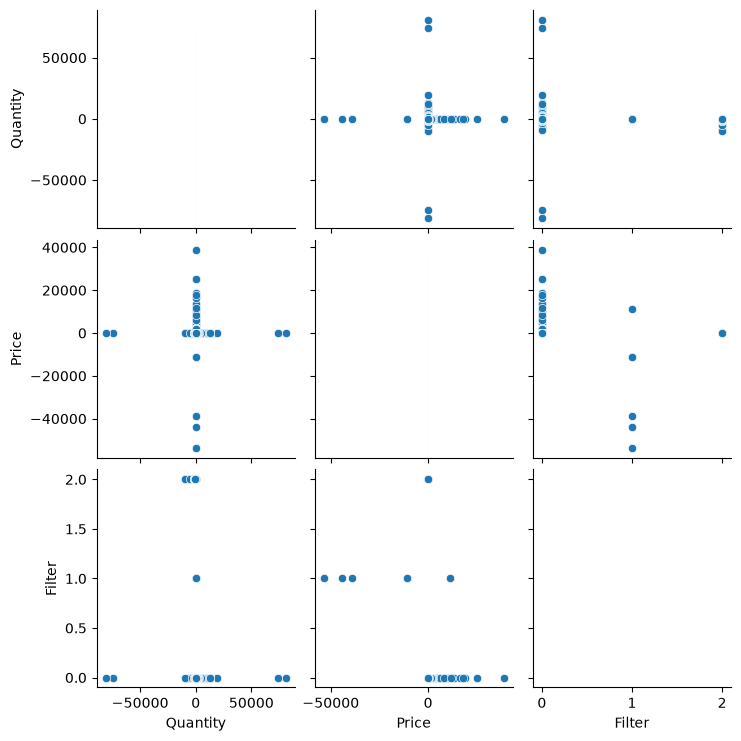

In [34]:
sns.pairplot(df)

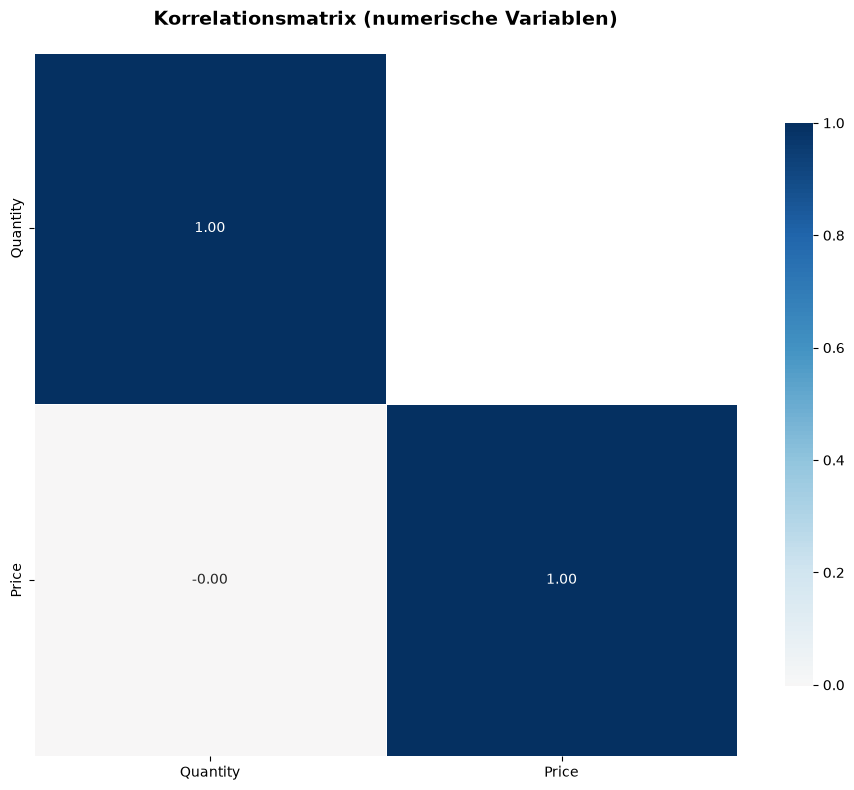


🔗 Stärkste Korrelationen (|r| > 0.5):

Keine starken Korrelationen gefunden.


In [33]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")


In [35]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")


📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT


NameError: name 'categorical_cols' is not defined